# Loan Default Risk — From Raw Data to Predictions
### A beginner-friendly, leakage-safe machine-learning project

**Goal:** predict the supplied `Risk_Flag` (0 / 1) from applicant information. The repository treats 1 as the positive risk class; the CSV does not define the observation window or prove that this is an observed loan default.

Inspired by the load → cleaning/features → exploration → modeling progression in **nyc.ipynb**, with each task separated into smaller cells. This is a classification project, so we use classification metrics instead of the taxi notebook's regression metrics.

**Our sequence:** load → structural audit → deterministic cleaning → repeated-profile check → protected splits → EDA → outlier review → feature engineering → preprocessing pipelines → baseline → three-fold CV / six models → imbalance experiment → XGBoost tuning → threshold selection → final validation → SHAP → save/reload → test predictions.

**Main improvements**
- Identical feature profiles stay together in every split and CV fold.
- Exploratory plots use the development partition only.
- A separate threshold partition chooses the decision cutoff; final validation stays sealed until evaluation.
- All learned imputation, scaling and category encoding happen inside a scikit-learn pipeline.
- The six models use the same benchmark rows and folds.
- No PCA: retaining understandable numeric and one-hot features is suitable here; PCA is not a compulsory modeling step.

**Libraries:** pandas, NumPy, Matplotlib, Seaborn, scikit-learn, XGBoost and SHAP. Saving uses Python's built-in `pickle`; there are no custom estimator classes or joblib calls.

Run cells from top to bottom in Jupyter, VS Code or Colab. The model comparison and tuning cells take the longest. Outputs are written to `loan_notebook_outputs` in your working directory. Results are computed here, not copied from the repository.


## 1. Install libraries — once if needed
Uncomment the next line only if imports fail. Restart the kernel after installing. `pickle`, `json` and `pathlib` are built into Python.


In [ ]:
# %pip install pandas numpy matplotlib seaborn scikit-learn xgboost shap


## 2. Imports and reproducible settings
`SEED` makes random choices repeatable. Benchmarking and tuning use group-preserving subsets to keep the notebook practical; the selected XGBoost settings are then fitted on all development rows. Increase the sample sizes for a more expensive comparison. They are approximate because an entire repeated-profile group must remain together.


In [ ]:
from pathlib import Path
import json
import pickle
import platform
import time
import importlib.metadata

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

from sklearn.base import clone
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.model_selection import StratifiedGroupKFold, cross_validate, RandomizedSearchCV
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, average_precision_score, precision_recall_curve,
    classification_report, ConfusionMatrixDisplay, RocCurveDisplay,
    PrecisionRecallDisplay, brier_score_loss)
from sklearn.calibration import calibration_curve
from xgboost import XGBClassifier
import shap

SEED = 42
BENCHMARK_ROWS = 12_000
TUNING_ROWS = 30_000
SEARCH_ITERATIONS = 6
MODEL_THREADS = 2
SHAP_ROWS = 200
OUTPUT = Path('loan_notebook_outputs')
OUTPUT.mkdir(exist_ok=True)
sns.set_theme(style='whitegrid', palette='Set2')
pd.set_option('display.max_columns', 30)

versions = {name: importlib.metadata.version(name) for name in
            ['pandas', 'numpy', 'scikit-learn', 'xgboost', 'shap', 'matplotlib', 'seaborn']}
display(pd.Series(versions, name='Installed version'))

def show_plot(filename):
    plt.tight_layout()
    plt.savefig(OUTPUT / filename, dpi=130, bbox_inches='tight')
    plt.show()
    plt.close('all')


C:\Users\KARUNESH G Y\Documents\Codex\2026-09-13\https-github-com-karangy7904-end-to\work\pydeps\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


pandas           3.0.5
numpy            2.5.3
scikit-learn     1.9.1
xgboost          3.4.1
shap            0.52.0
matplotlib      3.11.2
seaborn         0.13.2
Name: Installed version, dtype: str

## 3. Load the original CSV files
The paths below point to your supplied files. On another computer, change `DATA_DIR` to the folder containing both CSV files. We keep the original dataframes intact for traceability.


In [ ]:
DATA_DIR = Path(r'C:/Users/KARUNESH G Y/Downloads/RESUME/LOAN CLASSIFICATION')
# Portable alternative: DATA_DIR = Path('data')
TRAIN_PATH = DATA_DIR / 'Training Data.csv'
TEST_PATH = DATA_DIR / 'Test Data.csv'
assert TRAIN_PATH.exists() and TEST_PATH.exists(), 'Update DATA_DIR to your CSV folder.'
train_raw = pd.read_csv(TRAIN_PATH)
test_raw = pd.read_csv(TEST_PATH)
print('Training shape:', train_raw.shape, '| Test shape:', test_raw.shape)
display(train_raw.head())
display(test_raw.head())


Training shape: (252000, 13) | Test shape: (28000, 12)


,Id,Income,Age,Experience,Married/Single,House_Ownership,Car_Ownership,Profession,CITY,STATE,CURRENT_JOB_YRS,CURRENT_HOUSE_YRS,Risk_Flag
0,1,1303834,23,3,single,rented,no,Mechanical_engineer,Rewa,Madhya_Pradesh,3,13,0
1,2,7574516,40,10,single,rented,no,Software_Developer,Parbhani,Maharashtra,9,13,0
2,3,3991815,66,4,married,rented,no,Technical_writer,Alappuzha,Kerala,4,10,0
3,4,6256451,41,2,single,rented,yes,Software_Developer,Bhubaneswar,Odisha,2,12,1
4,5,5768871,47,11,single,rented,no,Civil_servant,Tiruchirappalli[10],Tamil_Nadu,3,14,1


,ID,Income,Age,Experience,Married/Single,House_Ownership,Car_Ownership,Profession,CITY,STATE,CURRENT_JOB_YRS,CURRENT_HOUSE_YRS
0,1,7393090,59,19,single,rented,no,Geologist,Malda,West Bengal,4,13
1,2,1215004,25,5,single,rented,no,Firefighter,Jalna,Maharashtra,5,10
2,3,8901342,50,12,single,rented,no,Lawyer,Thane,Maharashtra,9,14
3,4,1944421,49,9,married,rented,yes,Analyst,Latur,Maharashtra,3,12
4,5,13429,25,18,single,rented,yes,Comedian,Berhampore,West Bengal,13,11


## 4. Raw-data audit — structure, missing cells and IDs
This initial check is structural, not feature selection. The training file uses `Id`, whereas the test file uses `ID`. The test file has no target, so it cannot provide accuracy or F1.

The data includes income (currency/unit unspecified), age and experience in years, employment/housing tenure, marital status, ownership, profession, city and state. `Id` is a row identifier, not a predictor.


In [ ]:
TARGET = 'Risk_Flag'
NUMERIC = ['Income', 'Age', 'Experience', 'CURRENT_JOB_YRS', 'CURRENT_HOUSE_YRS']
CATEGORICAL = ['Married/Single', 'House_Ownership', 'Car_Ownership', 'Profession', 'CITY', 'STATE']
FEATURES = NUMERIC + CATEGORICAL

def audit_table(df):
    return pd.DataFrame({'dtype': df.dtypes.astype(str), 'missing': df.isna().sum(),
                         'missing_pct': df.isna().mean().mul(100),
                         'unique_values': df.nunique(dropna=False)})

display(audit_table(train_raw))
display(audit_table(test_raw))
assert set(train_raw.columns) == set(FEATURES + ['Id', TARGET])
assert set(test_raw.columns) == set(FEATURES + ['ID'])
assert train_raw[TARGET].notna().all() and set(train_raw[TARGET].unique()) == {0, 1}
assert train_raw['Id'].notna().all() and train_raw['Id'].is_unique
assert test_raw['ID'].notna().all() and test_raw['ID'].is_unique
print('Exact full-row duplicates:', train_raw.duplicated().sum())
audit_table(train_raw).to_csv(OUTPUT / 'raw_data_audit.csv')


,dtype,missing,missing_pct,unique_values
Id,int64,0,0.0,252000
Income,int64,0,0.0,41920
Age,int64,0,0.0,59
Experience,int64,0,0.0,21
Married/Single,str,0,0.0,2
House_Ownership,str,0,0.0,3
Car_Ownership,str,0,0.0,2
Profession,str,0,0.0,51
CITY,str,0,0.0,317
STATE,str,0,0.0,29


,dtype,missing,missing_pct,unique_values
ID,int64,0,0.0,28000
Income,int64,0,0.0,9916
Age,int64,0,0.0,59
Experience,int64,0,0.0,21
Married/Single,str,0,0.0,2
House_Ownership,str,0,0.0,3
Car_Ownership,str,0,0.0,2
Profession,str,0,0.0,51
CITY,str,0,0.0,317
STATE,str,0,0.0,29


Exact full-row duplicates: 0


## 5. Data cleaning — fixed rules only
We standardize headers and category spellings, convert numeric fields safely, and replace clearly invalid numeric values with missing values. These rules use no averages, quantiles or target information, so they can be applied before splitting.

We do **not** fill missing values yet: each training fold will learn its own medians and most-frequent categories. Extreme but plausible income values are retained. Rules deliberately avoid guessing adulthood/employment assumptions that the dataset does not document.


In [ ]:
def clean_data(df):
    result = df.copy()
    result.columns = result.columns.str.strip()
    result = result.rename(columns={'ID': 'Id'})
    for column in NUMERIC:
        result[column] = pd.to_numeric(result[column], errors='coerce')
        result[column] = result[column].replace([np.inf, -np.inf], np.nan)
        result.loc[result[column] < 0, column] = np.nan
    result.loc[result['Age'] <= 0, 'Age'] = np.nan
    for column in CATEGORICAL:
        result[column] = (result[column].astype('string').str.strip().str.lower()
                          .str.replace('_', ' ', regex=False)
                          .str.replace(r'\s+', ' ', regex=True))
        result[column] = result[column].replace('', pd.NA).astype(object)
        result[column] = result[column].where(pd.notna(result[column]), np.nan)
    return result

train = clean_data(train_raw)
test = clean_data(test_raw)
cleaning_report = pd.DataFrame({'missing_before': train_raw[FEATURES].isna().sum(),
                               'missing_after': train[FEATURES].isna().sum()})
display(cleaning_report)
print('Rows preserved:', len(train) == len(train_raw), len(test) == len(test_raw))
cleaning_report.to_csv(OUTPUT / 'cleaning_report.csv')


,missing_before,missing_after
Income,0,0
Age,0,0
Experience,0,0
CURRENT_JOB_YRS,0,0
CURRENT_HOUSE_YRS,0,0
Married/Single,0,0
House_Ownership,0,0
Car_Ownership,0,0
Profession,0,0
CITY,0,0


Rows preserved: True True


## 6. Repeated profiles — why a simple random split can mislead
Different IDs can contain exactly the same predictor values. We retain these records because repeated profiles are not proven data-entry mistakes; however, they must not appear on both sides of an evaluation split.

`hash_pandas_object` assigns a compact fingerprint to each cleaned feature combination, excluding ID and target. This is a practical **profile group**, not a verified borrower identifier. It prevents identical-profile overlap, but cannot detect near-duplicates or the same person with changed details. Conflicting labels are reported, not resolved by majority voting.


In [ ]:
groups = pd.util.hash_pandas_object(train[FEATURES], index=False)
profile_labels = pd.DataFrame({'group': groups, 'target': train[TARGET]})
group_summary = profile_labels.groupby('group')['target'].agg(['size', 'nunique'])
print('Unique feature profiles:', groups.nunique())
print('Repeated rows beyond the first profile occurrence:', groups.duplicated().sum())
print('Profiles containing both labels:', (group_summary['nunique'] > 1).sum())
display(group_summary['size'].describe().to_frame('Records per profile'))


Unique feature profiles: 42007
Repeated rows beyond the first profile occurrence: 209993
Profiles containing both labels: 1183


,Records per profile
count,42007.000000
mean,5.999000
std,12.266892
min,1.000000
25%,1.000000
50%,1.000000
75%,1.000000
max,40.000000


## 7. Create protected development, threshold and final-validation partitions
`StratifiedGroupKFold` tries to preserve the class proportions while keeping each profile group together. We take one of five folds for final validation, then one of five remaining folds for threshold selection: approximately **64% development / 16% threshold / 20% final validation**. Group sizes mean percentages are approximate.

Only development data drives plots, preprocessing choices, model comparisons and hyperparameter tuning. Threshold data is used once to choose the cutoff. Final-validation labels are used only in section 22. This replaces the repository's row-level split with a stricter unseen-profile evaluation, so the scores are not directly comparable.


In [ ]:
outer_split = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=SEED)
remaining_idx, final_idx = next(outer_split.split(train[FEATURES], train[TARGET], groups))
remaining = train.iloc[remaining_idx]
remaining_groups = groups.iloc[remaining_idx]
inner_split = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=SEED + 1)
dev_local, threshold_local = next(inner_split.split(
    remaining[FEATURES], remaining[TARGET], remaining_groups))

dev = remaining.iloc[dev_local].copy()
threshold_data = remaining.iloc[threshold_local].copy()
final_validation = train.iloc[final_idx].copy()  # keep sealed until section 22
g_dev = remaining_groups.iloc[dev_local]
g_threshold = remaining_groups.iloc[threshold_local]
g_final = groups.iloc[final_idx]
assert set(g_dev).isdisjoint(g_threshold)
assert set(g_dev).isdisjoint(g_final)
assert set(g_threshold).isdisjoint(g_final)
display(pd.DataFrame({'partition': ['Development', 'Threshold', 'Final validation'],
                      'rows': [len(dev), len(threshold_data), len(final_validation)]}))
split_manifest = pd.concat([
    pd.DataFrame({'Id': part['Id'], 'partition': name})
    for name, part in [('development', dev), ('threshold', threshold_data),
                       ('final_validation', final_validation)]])
split_manifest.to_csv(OUTPUT / 'split_manifest.csv', index=False)


,partition,rows
0,Development,161310
1,Threshold,40310
2,Final validation,50380


## 8. EDA — overview and class balance (development only)
Accuracy can look high when most records belong to class 0. We use **average precision (AP)** as the primary ranking metric and also report recall, precision and F1. AP summarizes the precision–recall curve; it is not the same calculation as trapezoidal PR-AUC.


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Income,161310.0,NaN,NaN,NaN,4996608.128027,2891197.795806,10310.0,2487959.0,5004535.0,7505547.0,9999938.0
Age,161310.0,NaN,NaN,NaN,50.184359,17.215103,21.0,35.0,50.0,65.0,79.0
Experience,161310.0,NaN,NaN,NaN,10.124933,6.002019,0.0,5.0,10.0,15.0,20.0
CURRENT_JOB_YRS,161310.0,NaN,NaN,NaN,6.367566,3.645006,0.0,4.0,6.0,9.0,14.0
CURRENT_HOUSE_YRS,161310.0,NaN,NaN,NaN,12.006081,1.390383,10.0,11.0,12.0,13.0,14.0
Married/Single,161310,2,single,144132,NaN,NaN,NaN,NaN,NaN,NaN,NaN
House_Ownership,161310,3,rented,148668,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Car_Ownership,161310,2,no,112010,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Profession,161310,51,physician,3860,NaN,NaN,NaN,NaN,NaN,NaN,NaN
CITY,161310,317,vijayanagaram,970,NaN,NaN,NaN,NaN,NaN,NaN,NaN


,count
Risk_Flag,
0,141456
1,19854


Development positive-class rate: 12.31%


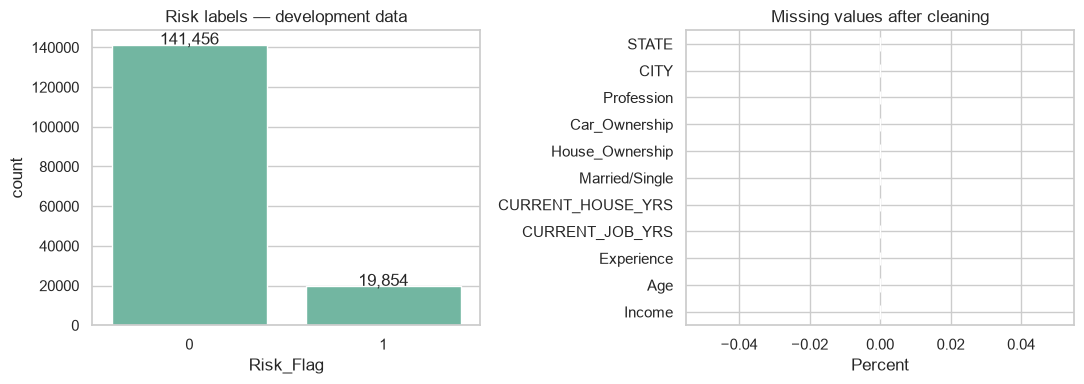

In [ ]:
display(dev[FEATURES].describe(include='all').T)
display(dev[TARGET].value_counts().rename_axis('Risk_Flag').to_frame('count'))
print(f'Development positive-class rate: {dev[TARGET].mean():.2%}')
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
sns.countplot(data=dev, x=TARGET, ax=axes[0])
axes[0].set_title('Risk labels — development data')
for bar in axes[0].patches:
    axes[0].annotate(f'{bar.get_height():,.0f}',
                    (bar.get_x() + bar.get_width()/2, bar.get_height()), ha='center')
dev[FEATURES].isna().mean().mul(100).sort_values().plot.barh(ax=axes[1])
axes[1].set(title='Missing values after cleaning', xlabel='Percent')
show_plot('01_class_balance_and_missing.png')


## 9. EDA — numerical distributions
Histograms show shape and skew. The overlaid class distributions are normalized separately, so the smaller risk class remains visible. Sampling here is only for faster plotting, not for model training.


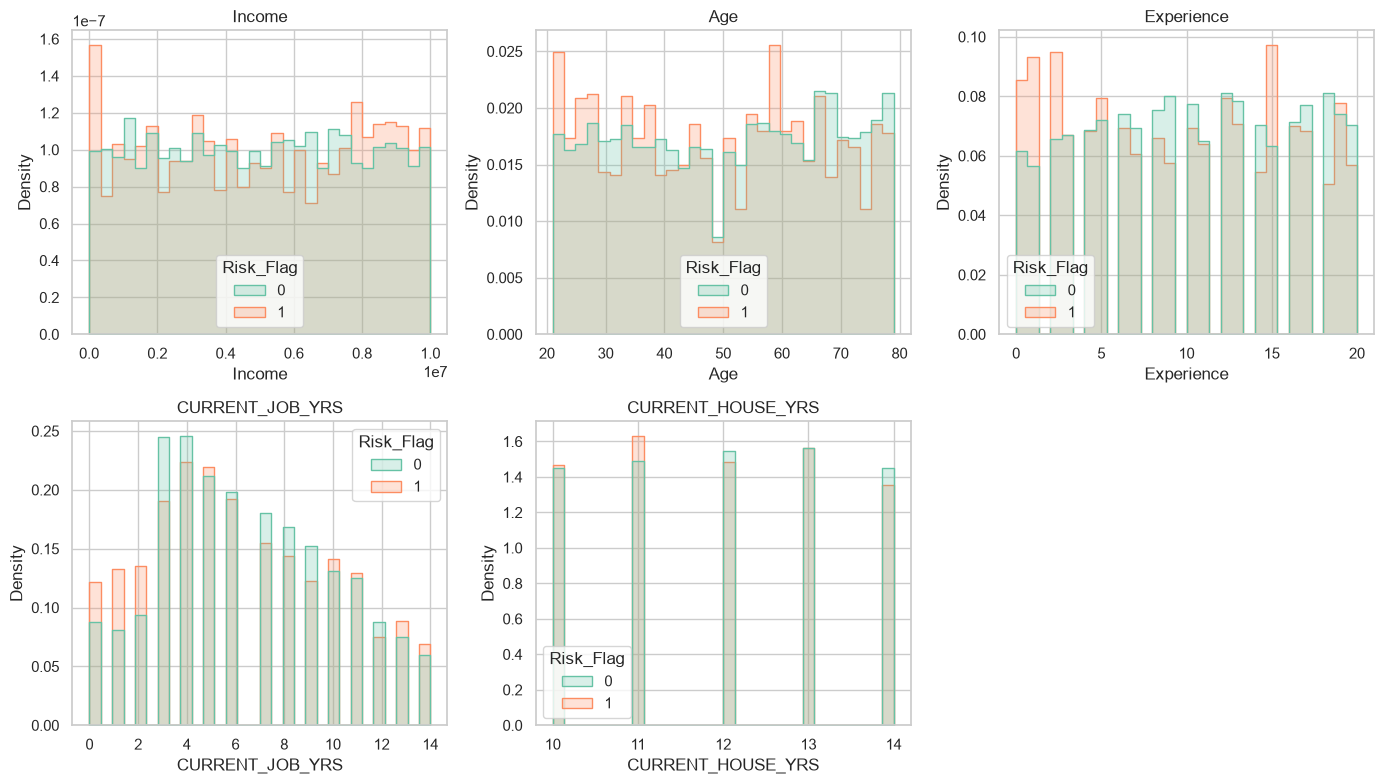

In [ ]:
eda_sample = dev.sample(n=min(20_000, len(dev)), random_state=SEED)
fig, axes = plt.subplots(2, 3, figsize=(14, 8))
for column, ax in zip(NUMERIC, axes.flat):
    sns.histplot(data=eda_sample, x=column, hue=TARGET, bins=30,
                 stat='density', common_norm=False, element='step', ax=ax)
    ax.set_title(column)
axes.flat[-1].axis('off')
show_plot('02_numeric_distributions.png')


## 10. EDA — box plots and outlier review
An IQR flag means unusually far from the central 50%, not necessarily wrong. These development-only bounds are diagnostic: we do not remove or cap rows using them. If clipping is added later, its limits must be learned within each training fold.


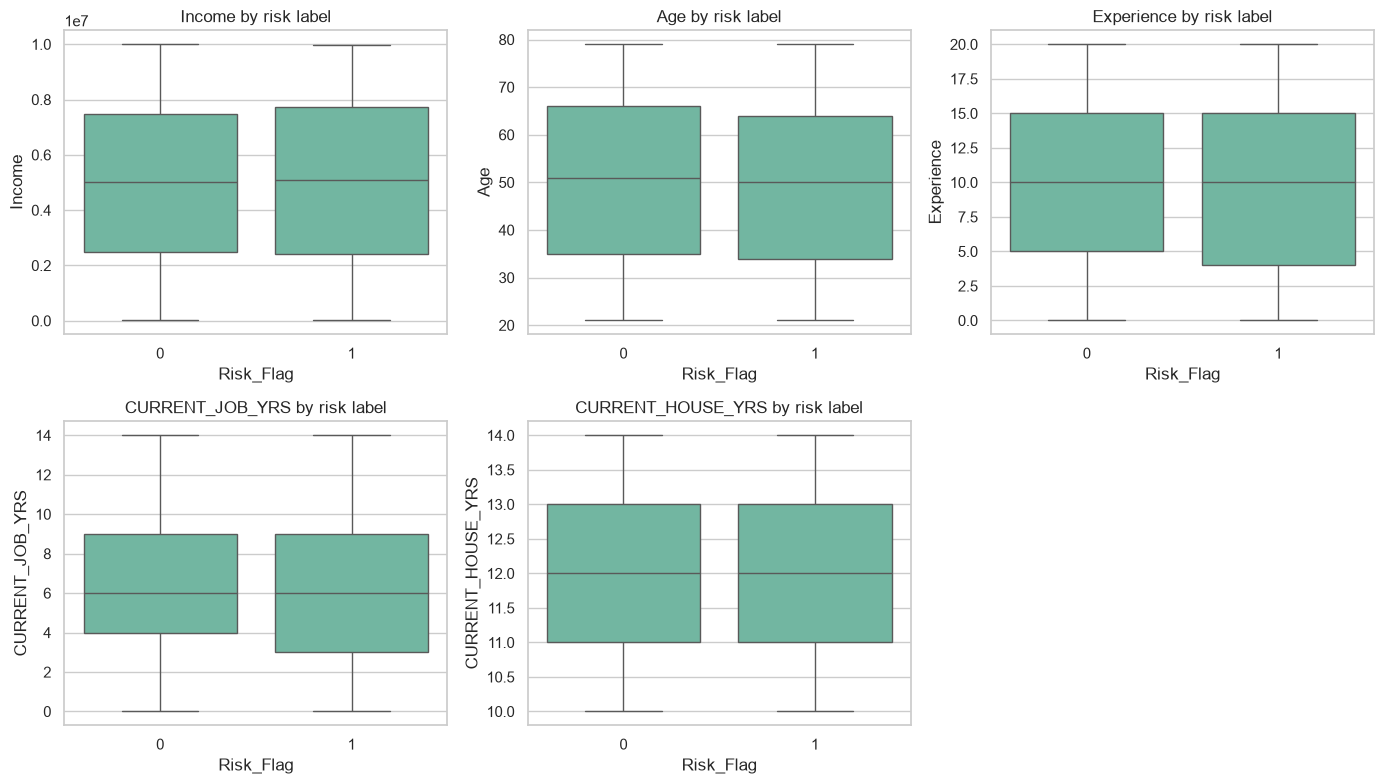

,feature,lower,upper,flagged_rows,flagged_pct
0,Income,-5038423.0,15031929.0,0,0.0
1,Age,-10.0,110.0,0,0.0
2,Experience,-10.0,30.0,0,0.0
3,CURRENT_JOB_YRS,-3.5,16.5,0,0.0
4,CURRENT_HOUSE_YRS,8.0,16.0,0,0.0


In [ ]:
fig, axes = plt.subplots(2, 3, figsize=(14, 8))
for column, ax in zip(NUMERIC, axes.flat):
    sns.boxplot(data=eda_sample, x=TARGET, y=column, ax=ax)
    ax.set_title(f'{column} by risk label')
axes.flat[-1].axis('off')
show_plot('03_boxplots.png')

outlier_rows = []
for column in NUMERIC:
    q1, q3 = dev[column].quantile([0.25, 0.75])
    iqr = q3 - q1
    low, high = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    flags = (dev[column] < low) | (dev[column] > high)
    outlier_rows.append({'feature': column, 'lower': low, 'upper': high,
                         'flagged_rows': int(flags.sum()), 'flagged_pct': flags.mean()*100})
outlier_report = pd.DataFrame(outlier_rows)
display(outlier_report)
outlier_report.to_csv(OUTPUT / 'outlier_review.csv', index=False)


## 11. EDA — correlation heatmap and consistency checks
Correlation shows linear association, not causation. Low correlation with the target does not imply a feature is useless to a tree model. We flag unusual tenure relationships for review without silently deleting them.


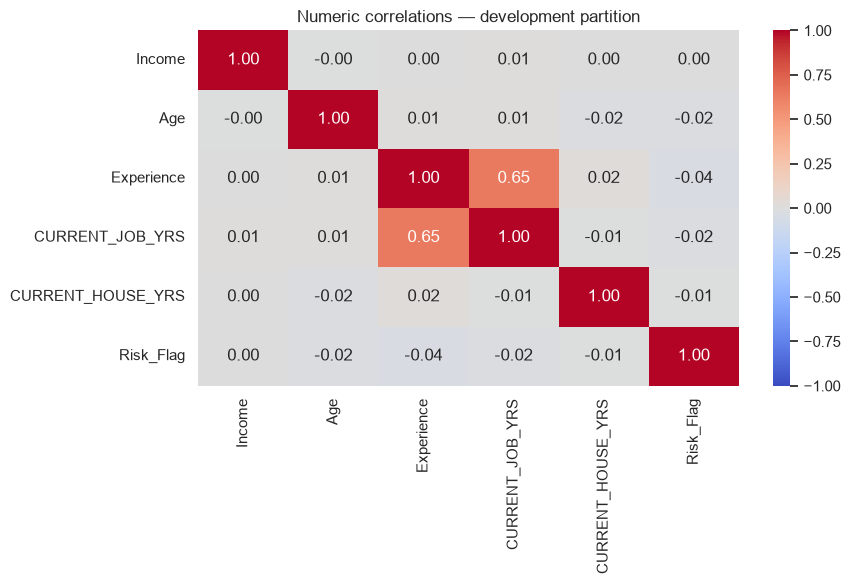

Experience greater than age                 0
Current job longer than total experience    0
Current house tenure greater than age       0
Name: Review count, dtype: int64

In [ ]:
plt.figure(figsize=(9, 6))
sns.heatmap(dev[NUMERIC + [TARGET]].corr(), annot=True, fmt='.2f',
            cmap='coolwarm', center=0, vmin=-1, vmax=1)
plt.title('Numeric correlations — development partition')
show_plot('04_correlation_heatmap.png')
display(pd.Series({
    'Experience greater than age': int((dev['Experience'] > dev['Age']).sum()),
    'Current job longer than total experience': int((dev['CURRENT_JOB_YRS'] > dev['Experience']).sum()),
    'Current house tenure greater than age': int((dev['CURRENT_HOUSE_YRS'] > dev['Age']).sum())
}, name='Review count'))


## 12. EDA — categorical counts and observed risk rates
For each field, show its 10 most frequent categories, selected by count rather than risk rate. Read the risk-rate plot alongside the count plot: small groups have less reliable rates. Categories with fewer than 100 development records are excluded from these plots. These associations are descriptive and do not establish causes.


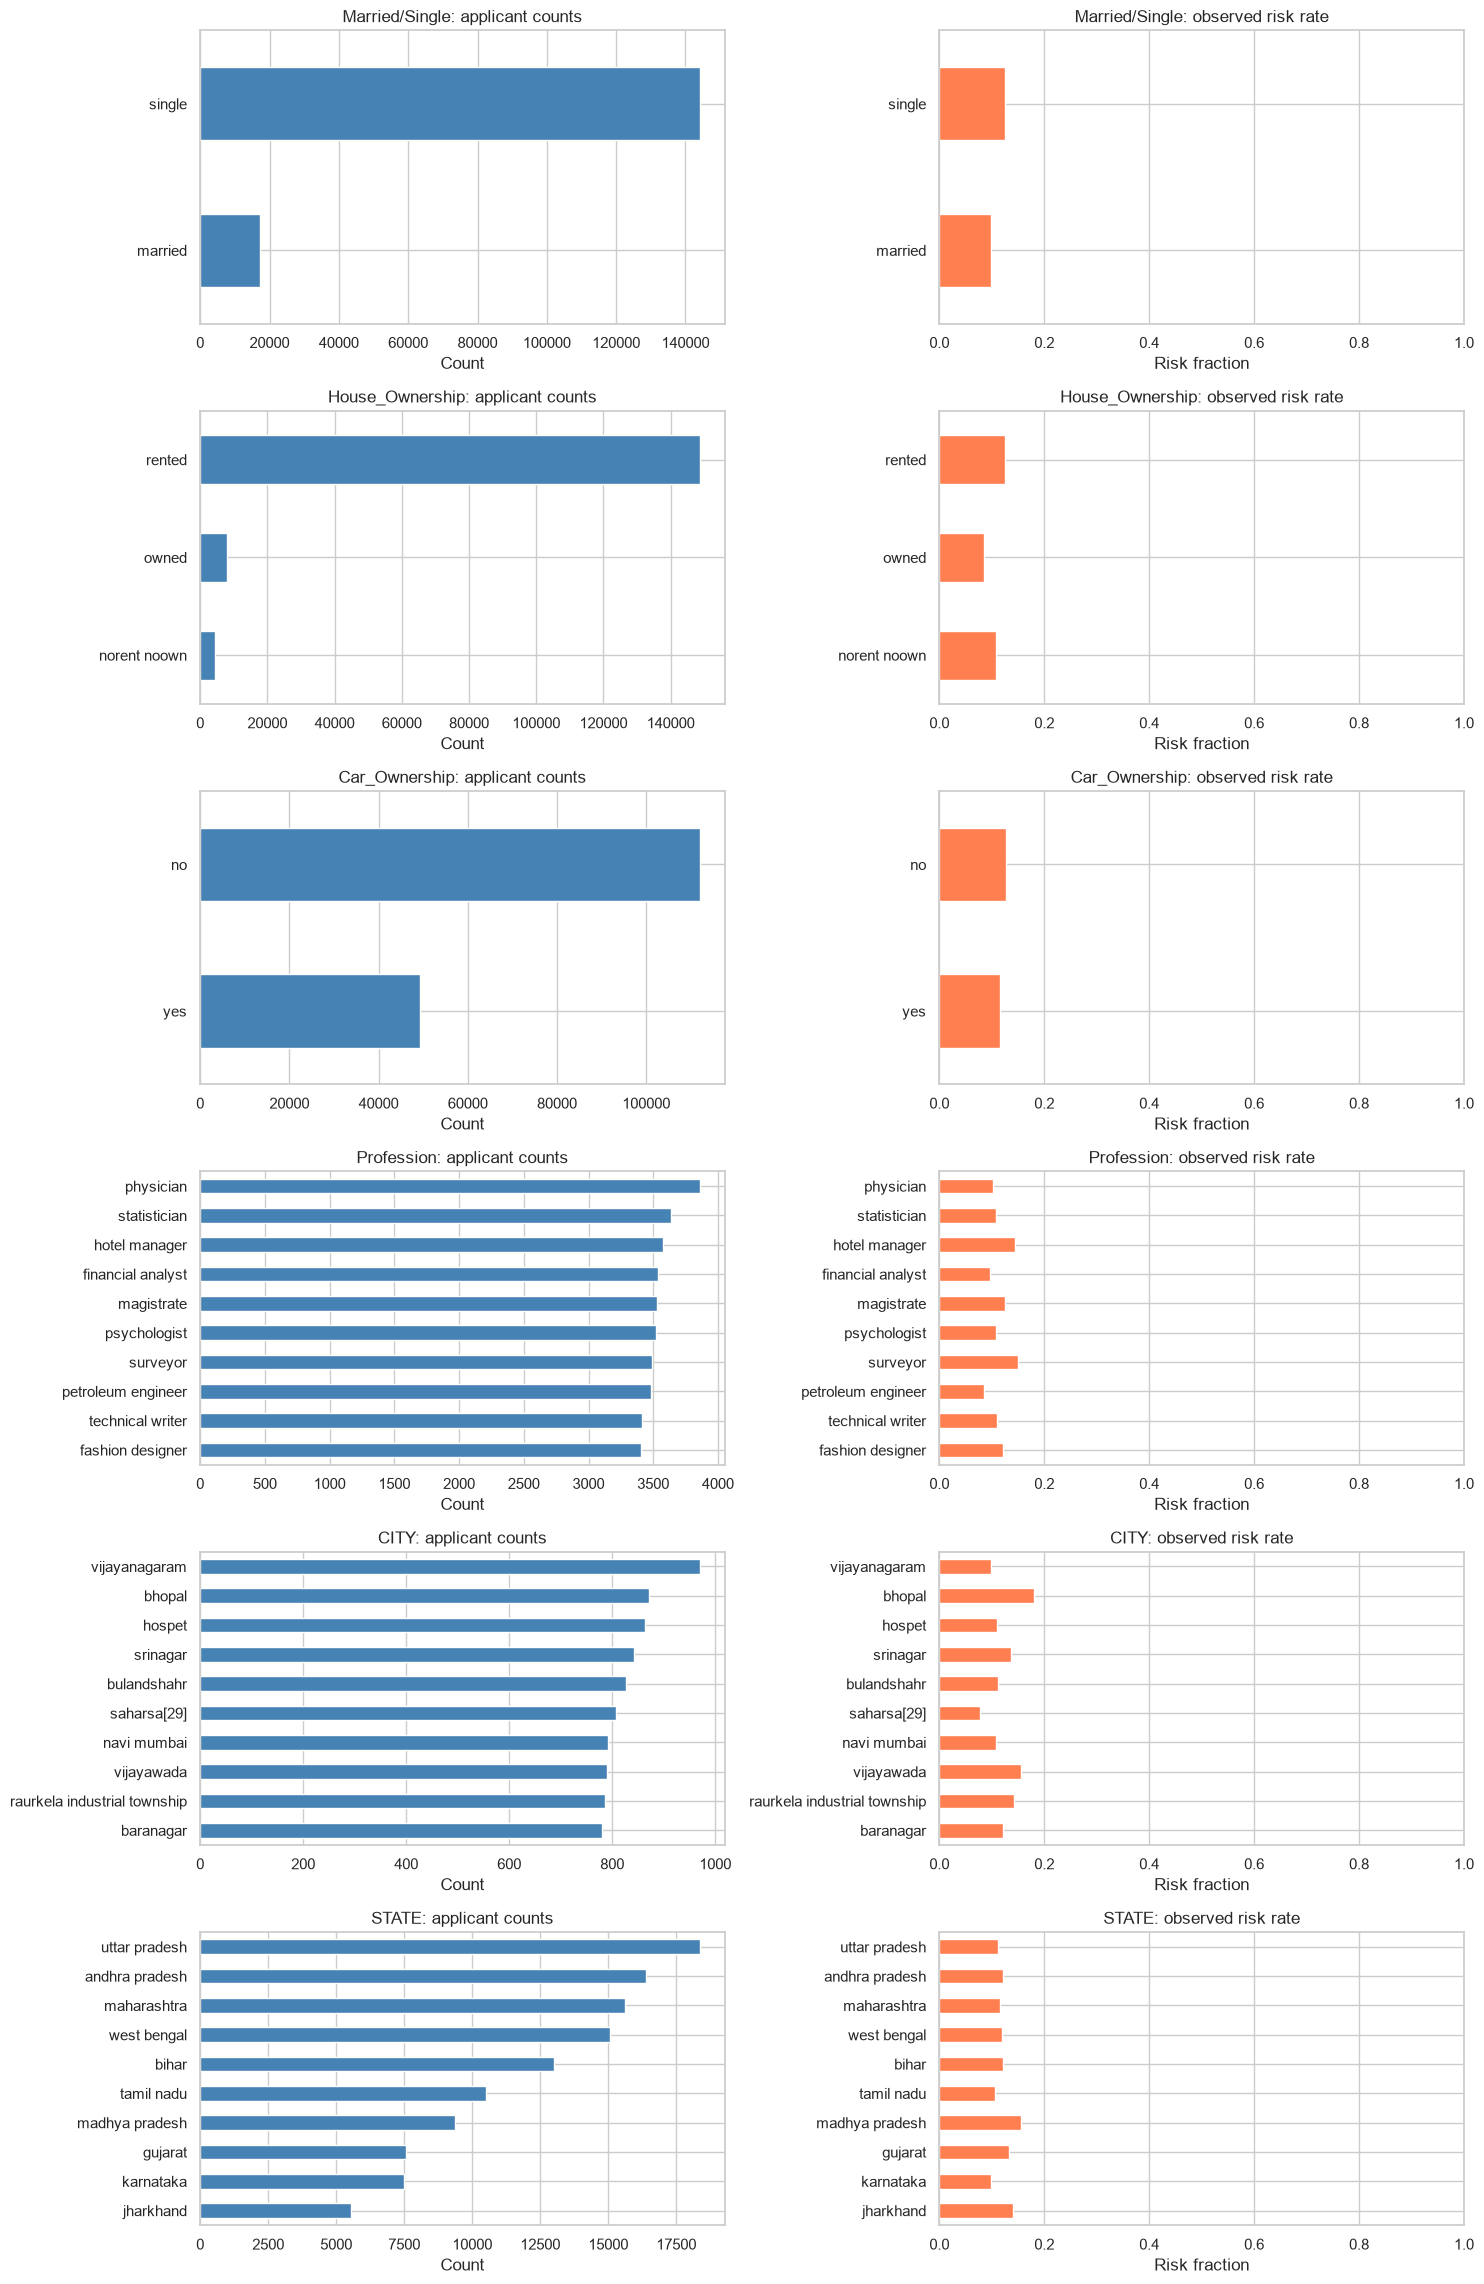

In [ ]:
fig, axes = plt.subplots(len(CATEGORICAL), 2, figsize=(15, 23))
for row, column in enumerate(CATEGORICAL):
    summary = dev.groupby(column, dropna=False)[TARGET].agg(count='size', risk_rate='mean')
    summary = summary[summary['count'] >= 100].nlargest(10, 'count').sort_values('count')
    summary['count'].plot.barh(ax=axes[row, 0], color='steelblue')
    summary['risk_rate'].plot.barh(ax=axes[row, 1], color='coral')
    axes[row, 0].set(title=f'{column}: applicant counts', ylabel='', xlabel='Count')
    axes[row, 1].set(title=f'{column}: observed risk rate', ylabel='', xlabel='Risk fraction', xlim=(0, 1))
show_plot('05_categorical_counts_and_rates.png')


## 13. EDA conclusions and cleaning decisions
Summarize what the actual charts show, rather than assuming a business story:
- Compare the positive-class rate with the accuracy baseline below.
- Check numerical overlap between classes; overlapping plots suggest no single obvious cutoff.
- Review extreme values and category sample sizes before interpreting their rates.
- Keep plausible outliers and repeated records; protect evaluation with profile groups.
- Use imputation and unknown-category handling even if these particular CSVs contain no missing values.
- Keep all documented raw predictors initially. Identifier and target never enter the feature matrix.

Age, marital status and geography can be sensitive or act as proxies. Their inclusion follows the educational dataset; SHAP associations are not an eligibility justification. This notebook does not validate use in real lending decisions.


## 14. Feature engineering — simple, deterministic formulas
Each new feature uses values from the same row, so nothing is fitted here. We retain the original numeric fields too. The `+1` protects ratios when experience is zero; names and explanations make that smoothing explicit.

| Feature | Meaning |
|---|---|
| LOG_INCOME | `log(1 + Income)` compresses the scale |
| INCOME_PER_EXPERIENCE_PLUS_ONE | Income divided by experience + 1 |
| JOB_STABILITY_RATIO | Current job years divided by experience + 1 |
| HOUSE_TENURE_AGE_RATIO | Current housing tenure divided by age + 1 |
| AGE_MINUS_EXPERIENCE | Approximate starting-age proxy, not a verified start date |

These are reasonable hypotheses, not guaranteed improvements. A future ablation study should compare raw versus engineered features using development CV, never final validation. We omit arbitrary income bands and PCA to keep the feature meaning clear.


In [ ]:
def engineer_features(df):
    result = df[FEATURES].copy()  # explicitly excludes ID and target
    result['LOG_INCOME'] = np.log1p(result['Income'])
    result['INCOME_PER_EXPERIENCE_PLUS_ONE'] = result['Income'] / (result['Experience'] + 1)
    result['JOB_STABILITY_RATIO'] = result['CURRENT_JOB_YRS'] / (result['Experience'] + 1)
    result['HOUSE_TENURE_AGE_RATIO'] = result['CURRENT_HOUSE_YRS'] / (result['Age'] + 1)
    result['AGE_MINUS_EXPERIENCE'] = result['Age'] - result['Experience']
    return result.replace([np.inf, -np.inf], np.nan)

X_dev = engineer_features(dev)
y_dev = dev[TARGET].astype(int)
display(X_dev.head())
assert 'Id' not in X_dev and TARGET not in X_dev
print('Raw predictor count:', len(FEATURES), '| Engineered predictor count:', X_dev.shape[1])


,Income,Age,Experience,CURRENT_JOB_YRS,CURRENT_HOUSE_YRS,Married/Single,House_Ownership,Car_Ownership,Profession,CITY,STATE,LOG_INCOME,INCOME_PER_EXPERIENCE_PLUS_ONE,JOB_STABILITY_RATIO,HOUSE_TENURE_AGE_RATIO,AGE_MINUS_EXPERIENCE
0,1303834.0,23.0,3.0,3.0,13.0,single,rented,no,mechanical engineer,rewa,madhya pradesh,14.080820,3.259585e+05,0.750000,0.541667,20.0
1,7574516.0,40.0,10.0,9.0,13.0,single,rented,no,software developer,parbhani,maharashtra,15.840300,6.885924e+05,0.818182,0.317073,30.0
2,3991815.0,66.0,4.0,4.0,10.0,married,rented,no,technical writer,alappuzha,kerala,15.199757,7.983630e+05,0.800000,0.149254,62.0
3,6256451.0,41.0,2.0,2.0,12.0,single,rented,yes,software developer,bhubaneswar,odisha,15.649124,2.085484e+06,0.666667,0.285714,39.0
5,6915937.0,64.0,0.0,0.0,12.0,single,rented,no,civil servant,jalgaon,maharashtra,15.749339,6.915937e+06,0.000000,0.184615,64.0


Raw predictor count: 11 | Engineered predictor count: 16


## 15. Leakage-safe numeric and categorical pipelines
**Numeric:** fill missing values with the training-fold median, then standardize. Scaling helps logistic regression and SVM; it is harmless for trees.

**Categorical:** fill with the training-fold most frequent category, then one-hot encode. `handle_unknown='ignore'` lets inference accept unseen categories. `min_frequency=5` reduces very rare category columns based only on the fitted fold.

`ColumnTransformer` applies the two recipes to the right columns. `Pipeline` fits preprocessing and the model together during CV. We never preprocess the full dataset with `fit_transform` before splitting. Sparse output avoids unnecessarily large one-hot tables.


In [ ]:
numeric_columns = X_dev.select_dtypes(include='number').columns.tolist()
categorical_columns = CATEGORICAL.copy()

numeric_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])
categorical_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(handle_unknown='ignore', min_frequency=5, sparse_output=True))
])
preprocessor = ColumnTransformer([
    ('numeric', numeric_pipeline, numeric_columns),
    ('categorical', categorical_pipeline, categorical_columns)
], sparse_threshold=1.0)

def make_pipeline(model):
    return Pipeline([('preprocessing', clone(preprocessor)), ('model', model)])


## 16. Fair benchmark sample, three-fold CV and metrics
All six models see the same development subset and the same three group-stratified folds. The subset keeps whole profiles; its size is approximate. The SVM therefore gets a manageable sample without making its comparison use different data.

**AP / ROC-AUC:** ranking quality. **Precision:** how often positive alerts are correct. **Recall:** how many positive records are found. **F1:** balances precision and recall. CV F1 uses each model's default decision rule (SVC uses its decision score; we do not pretend it is a probability).

CV standard deviation measures variation across these three folds, not a confidence interval. These scores guide development; only the sealed partition later gives the final estimate.


In [ ]:
def group_sample(X, y, group_ids, approximate_rows):
    if len(X) <= approximate_rows:
        return X.copy(), y.copy(), group_ids.copy()
    folds = max(2, int(np.ceil(len(X) / approximate_rows)))
    sampler = StratifiedGroupKFold(n_splits=folds, shuffle=True, random_state=SEED)
    _, selected = next(sampler.split(X, y, group_ids))
    return X.iloc[selected], y.iloc[selected], group_ids.iloc[selected]

X_bench, y_bench, g_bench = group_sample(X_dev, y_dev, g_dev, BENCHMARK_ROWS)
cv = StratifiedGroupKFold(n_splits=3, shuffle=True, random_state=SEED)
cv_splits = list(cv.split(X_bench, y_bench, g_bench))
for fit_idx, score_idx in cv_splits:
    assert set(g_bench.iloc[fit_idx]).isdisjoint(g_bench.iloc[score_idx])
print('Benchmark rows:', len(X_bench), '| positive fraction:', round(y_bench.mean(), 4))
scoring = {'ap': 'average_precision', 'roc_auc': 'roc_auc',
           'f1': 'f1', 'accuracy': 'accuracy'}
benchmark_results = []

def evaluate_cv(name, estimator):
    scores = cross_validate(make_pipeline(estimator), X_bench, y_bench,
                            cv=cv_splits, scoring=scoring, n_jobs=1,
                            return_train_score=True, error_score='raise')
    row = {'model': name, 'AP_mean': scores['test_ap'].mean(),
           'AP_std': scores['test_ap'].std(), 'ROC_AUC': scores['test_roc_auc'].mean(),
           'F1': scores['test_f1'].mean(), 'accuracy': scores['test_accuracy'].mean(),
           'train_AP': scores['train_ap'].mean(), 'fit_seconds': scores['fit_time'].mean()}
    benchmark_results.append(row)
    display(pd.DataFrame([row]).round(4))
    return row


Benchmark rows: 11511 | positive fraction: 0.1228


## 17. Baseline — predict the majority class
A useful model should improve on a no-skill baseline. Predicting 0 for everyone may have high accuracy while having zero positive recall. This baseline is additional to the six real models.


In [ ]:
baseline_result = evaluate_cv('Dummy baseline', DummyClassifier(strategy='most_frequent'))


,model,AP_mean,AP_std,ROC_AUC,F1,accuracy,train_AP,fit_seconds
0,Dummy baseline,0.1228,0.0016,0.5,0.0,0.8772,0.1228,0.0502


## 18. Six models — one model per cell
The first comparison uses each model without explicit class balancing. Section 19 then demonstrates the effect of balancing on the same folds, keeping that decision visible.


### 18.1 Logistic regression
A simple linear classification baseline. It estimates a weighted combination of the encoded features and converts it to a probability.


In [ ]:
logistic_result = evaluate_cv('Logistic regression',
    LogisticRegression(max_iter=2000, random_state=SEED))


,model,AP_mean,AP_std,ROC_AUC,F1,accuracy,train_AP,fit_seconds
0,Logistic regression,0.1137,0.0096,0.4726,0.0198,0.8125,0.5897,0.0866


### 18.2 Decision tree
Learns if/else splits. Limiting depth and requiring multiple records per leaf reduces memorization.


In [ ]:
tree_result = evaluate_cv('Decision tree',
    DecisionTreeClassifier(max_depth=10, min_samples_leaf=20, random_state=SEED))


,model,AP_mean,AP_std,ROC_AUC,F1,accuracy,train_AP,fit_seconds
0,Decision tree,0.129,0.0145,0.4797,0.0083,0.8484,0.4141,0.0713


### 18.3 Random forest
Averages many trees trained with randomness. It usually generalizes better than one unrestricted tree.


In [ ]:
forest_result = evaluate_cv('Random forest',
    RandomForestClassifier(n_estimators=120, max_depth=16, min_samples_leaf=5,
                           n_jobs=MODEL_THREADS, random_state=SEED))


,model,AP_mean,AP_std,ROC_AUC,F1,accuracy,train_AP,fit_seconds
0,Random forest,0.1292,0.0092,0.5172,0.0,0.8772,0.6353,0.3625


### 18.4 Gradient boosting
Builds trees sequentially so later trees address errors remaining from earlier ones.


In [ ]:
gradient_result = evaluate_cv('Gradient boosting',
    GradientBoostingClassifier(n_estimators=80, learning_rate=0.07,
                               max_depth=3, random_state=SEED))


,model,AP_mean,AP_std,ROC_AUC,F1,accuracy,train_AP,fit_seconds
0,Gradient boosting,0.1296,0.0104,0.5158,0.0,0.8673,0.5787,0.7166


### 18.5 Support vector machine (RBF)
Finds a nonlinear boundary. `probability=False` avoids extra probability-fitting work; scikit-learn uses its decision scores for AP and ROC-AUC. This model can still be slow as sample size increases.


In [ ]:
svm_result = evaluate_cv('RBF SVM',
    SVC(C=1.0, kernel='rbf', probability=False, cache_size=512, random_state=SEED))


C:\Users\KARUNESH G Y\Documents\Codex\2026-09-13\https-github-com-karangy7904-end-to\work\pydeps\sklearn\svm\_base.py:236: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(


C:\Users\KARUNESH G Y\Documents\Codex\2026-09-13\https-github-com-karangy7904-end-to\work\pydeps\sklearn\svm\_base.py:236: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(


C:\Users\KARUNESH G Y\Documents\Codex\2026-09-13\https-github-com-karangy7904-end-to\work\pydeps\sklearn\svm\_base.py:236: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(


,model,AP_mean,AP_std,ROC_AUC,F1,accuracy,train_AP,fit_seconds
0,RBF SVM,0.1457,0.0303,0.5244,0.0,0.8771,0.5833,0.5456


### 18.6 XGBoost
An efficient gradient-boosted tree model. `tree_method='hist'` speeds fitting and regularization controls complexity. It is the preselected focus of our later tuning exercise, not automatically the winner of this comparison.


In [ ]:
xgb_base = XGBClassifier(n_estimators=150, max_depth=5, learning_rate=0.07,
                         subsample=0.85, colsample_bytree=0.85, tree_method='hist',
                         eval_metric='logloss', n_jobs=MODEL_THREADS, random_state=SEED)
xgb_result = evaluate_cv('XGBoost', xgb_base)


,model,AP_mean,AP_std,ROC_AUC,F1,accuracy,train_AP,fit_seconds
0,XGBoost,0.1202,0.0124,0.4524,0.0242,0.8731,0.6568,0.1453


### 18.7 Compare the results
Rank by held-out-fold AP, then inspect its variability, training–CV gap and runtime. A large training–CV gap suggests overfitting. Do not select by training score or compare these unseen-profile results directly with the repository's random-row validation results.


,model,AP_mean,AP_std,ROC_AUC,F1,accuracy,train_AP,fit_seconds
5,RBF SVM,0.1457,0.0303,0.5244,0.0000,0.8771,0.5833,0.5456
4,Gradient boosting,0.1296,0.0104,0.5158,0.0000,0.8673,0.5787,0.7166
3,Random forest,0.1292,0.0092,0.5172,0.0000,0.8772,0.6353,0.3625
2,Decision tree,0.1290,0.0145,0.4797,0.0083,0.8484,0.4141,0.0713
0,Dummy baseline,0.1228,0.0016,0.5000,0.0000,0.8772,0.1228,0.0502
6,XGBoost,0.1202,0.0124,0.4524,0.0242,0.8731,0.6568,0.1453
1,Logistic regression,0.1137,0.0096,0.4726,0.0198,0.8125,0.5897,0.0866


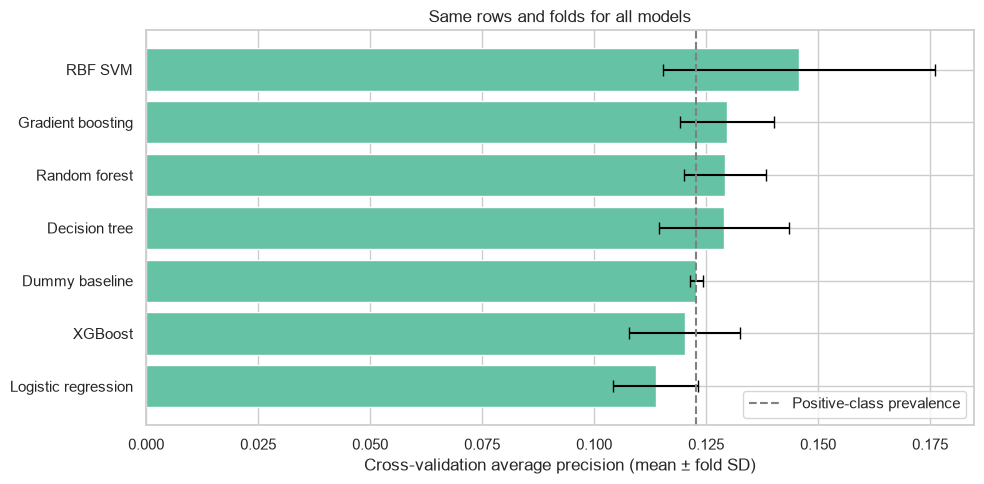

In [ ]:
comparison = pd.DataFrame(benchmark_results).sort_values('AP_mean', ascending=False)
display(comparison.round(4))
comparison.to_csv(OUTPUT / 'six_model_comparison.csv', index=False)
ordered = comparison.sort_values('AP_mean')
plt.figure(figsize=(10, 5))
plt.barh(ordered['model'], ordered['AP_mean'], xerr=ordered['AP_std'], capsize=4)
plt.axvline(y_bench.mean(), color='gray', linestyle='--', label='Positive-class prevalence')
plt.xlabel('Cross-validation average precision (mean ± fold SD)')
plt.title('Same rows and folds for all models')
plt.legend()
show_plot('06_model_comparison.png')


## 19. Class imbalance — a separate experiment
We compare unweighted and balanced logistic regression using the same folds. `class_weight='balanced'` calculates weights from the labels passed to each fit, so validation-fold labels do not determine its weights.

For XGBoost, section 20 searches explicit `scale_pos_weight` candidates (1, 3 and 7) inside CV. Larger values penalize missed positives more. We do not apply SMOTE before splitting or invent intermediate one-hot categories. Class weighting may help recall while hurting precision or probability calibration; the CV results decide which XGBoost setting to use.


In [ ]:
balanced_result = evaluate_cv('Logistic regression (balanced)',
    LogisticRegression(max_iter=2000, class_weight='balanced', random_state=SEED))
imbalance_comparison = pd.DataFrame([logistic_result, balanced_result])
display(imbalance_comparison[['model', 'AP_mean', 'F1', 'accuracy']].round(4))
imbalance_comparison.to_csv(OUTPUT / 'imbalance_comparison.csv', index=False)


,model,AP_mean,AP_std,ROC_AUC,F1,accuracy,train_AP,fit_seconds
0,Logistic regression (balanced),0.1133,0.0072,0.4639,0.1364,0.5453,0.5466,0.1096


,model,AP_mean,F1,accuracy
0,Logistic regression,0.1137,0.0198,0.8125
1,Logistic regression (balanced),0.1133,0.1364,0.5453


## 20. Randomized XGBoost hyperparameter tuning
We search a small set of combinations using three group-stratified CV folds on development data. Every candidate refits its preprocessing within the fold. We optimize AP, not final-validation accuracy.

`n_estimators`: number of trees; `max_depth`: complexity; `learning_rate`: step size; `min_child_weight`: minimum support for splits; `subsample`/`colsample_bytree`: randomness; `reg_lambda`: regularization; `scale_pos_weight`: positive-class emphasis.

Six random combinations are an affordable starting point, not an exhaustive optimization. XGBoost remains the planned final model for this teaching project even if another benchmark model leads. A claim that it is the best model would require equally thorough tuning of the other contenders. The search's best CV score is a selection score, not an unbiased final estimate.


In [ ]:
X_tune, y_tune, g_tune = group_sample(X_dev, y_dev, g_dev, TUNING_ROWS)
parameter_choices = {
    'model__n_estimators': [150, 250, 350],
    'model__max_depth': [3, 5, 7],
    'model__learning_rate': [0.03, 0.07, 0.12],
    'model__min_child_weight': [1, 5, 10],
    'model__subsample': [0.8, 1.0],
    'model__colsample_bytree': [0.8, 1.0],
    'model__reg_lambda': [1, 5, 10],
    'model__scale_pos_weight': [1, 3, 7]
}
search = RandomizedSearchCV(
    make_pipeline(clone(xgb_base)), param_distributions=parameter_choices,
    n_iter=SEARCH_ITERATIONS, scoring='average_precision',
    cv=StratifiedGroupKFold(n_splits=3, shuffle=True, random_state=SEED),
    random_state=SEED, n_jobs=1, verbose=1, refit=True, error_score='raise')
search.fit(X_tune, y_tune, groups=g_tune)
print('Tuning rows:', len(X_tune))
print('Best development CV AP:', round(search.best_score_, 4))
display(pd.Series(search.best_params_, name='Selected setting'))
tuning_results = pd.DataFrame(search.cv_results_).sort_values('rank_test_score')
display(tuning_results[['rank_test_score', 'mean_test_score', 'std_test_score', 'params']].head())
tuning_results.to_csv(OUTPUT / 'xgboost_search_results.csv', index=False)


Fitting 3 folds for each of 6 candidates, totalling 18 fits


Tuning rows: 26889
Best development CV AP: 0.1234


model__subsample             0.80
model__scale_pos_weight      3.00
model__reg_lambda           10.00
model__n_estimators        350.00
model__min_child_weight     10.00
model__max_depth             3.00
model__learning_rate         0.12
model__colsample_bytree      0.80
Name: Selected setting, dtype: float64

,rank_test_score,mean_test_score,std_test_score,params
2,1,0.123441,0.003281,"{'model__subsample': 0.8, 'model__scale_pos_we..."
4,2,0.123225,0.003808,"{'model__subsample': 0.8, 'model__scale_pos_we..."
5,3,0.122909,0.006379,"{'model__subsample': 1.0, 'model__scale_pos_we..."
1,4,0.122868,0.002975,"{'model__subsample': 0.8, 'model__scale_pos_we..."
0,5,0.122585,0.009472,"{'model__subsample': 0.8, 'model__scale_pos_we..."


## 21. Fit on all development rows, then choose the threshold
The model is fitted on development data only. We next predict the separate threshold partition and choose the cutoff with the highest F1. This is a transparent demonstration objective, not a business cost model. The threshold-partition F1 is optimistically selected and is **not** reported as final performance.

The fitted model is not refitted after cutoff selection. This keeps the selected cutoff attached to the exact model that will be evaluated and saved. A weighted classifier's outputs are scores on a probability scale; calibration should be checked before treating them as reliable default probabilities.


Frozen decision threshold: 0.1967


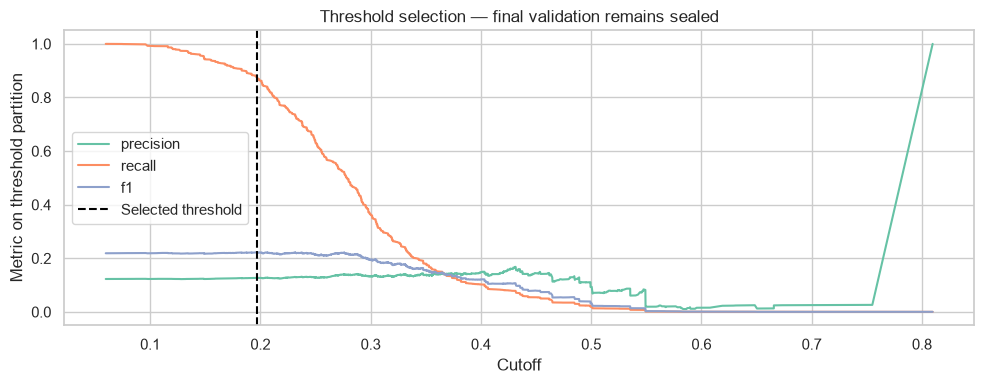

In [ ]:
final_model = clone(search.best_estimator_)
final_model.fit(X_dev, y_dev)

X_threshold = engineer_features(threshold_data)
y_threshold = threshold_data[TARGET].astype(int)
threshold_scores = final_model.predict_proba(X_threshold)[:, 1]
precisions, recalls, thresholds = precision_recall_curve(y_threshold, threshold_scores)
f1_values = 2 * precisions[:-1] * recalls[:-1] / np.maximum(precisions[:-1] + recalls[:-1], 1e-12)
best_index = int(np.argmax(f1_values))
selected_threshold = float(thresholds[best_index])
print(f'Frozen decision threshold: {selected_threshold:.4f}')

threshold_table = pd.DataFrame({'threshold': thresholds, 'precision': precisions[:-1],
                                'recall': recalls[:-1], 'f1': f1_values})
threshold_table.to_csv(OUTPUT / 'threshold_analysis.csv', index=False)
plt.figure(figsize=(10, 4))
for metric in ['precision', 'recall', 'f1']:
    plt.plot(threshold_table['threshold'], threshold_table[metric], label=metric)
plt.axvline(selected_threshold, color='black', linestyle='--', label='Selected threshold')
plt.xlabel('Cutoff'); plt.ylabel('Metric on threshold partition')
plt.title('Threshold selection — final validation remains sealed')
plt.legend()
show_plot('07_threshold_selection.png')


## 22. Untouched final-validation evaluation
This is the first model evaluation on the final partition. We show both the default 0.5 rule and the already frozen cutoff for context, but do not choose between them using these results. Neither model settings nor the threshold should be changed after looking here.

AP and ROC-AUC do not change with the cutoff. Precision, recall and F1 do. If results are disappointing, report that honestly; further development requires fresh holdout data for a new final assessment.


In [ ]:
X_final = engineer_features(final_validation)
y_final = final_validation[TARGET].astype(int)
final_scores = final_model.predict_proba(X_final)[:, 1]
final_predictions = (final_scores >= selected_threshold).astype(int)

def metric_row(name, y_true, scores, cutoff):
    predicted = (scores >= cutoff).astype(int)
    return {'rule': name, 'threshold': cutoff,
            'AP': average_precision_score(y_true, scores),
            'ROC_AUC': roc_auc_score(y_true, scores),
            'accuracy': accuracy_score(y_true, predicted),
            'precision': precision_score(y_true, predicted, zero_division=0),
            'recall': recall_score(y_true, predicted, zero_division=0),
            'F1': f1_score(y_true, predicted, zero_division=0),
            'Brier_score': brier_score_loss(y_true, scores)}

final_metrics = pd.DataFrame([
    metric_row('Default 0.5 (reference)', y_final, final_scores, 0.5),
    metric_row('Frozen F1 cutoff', y_final, final_scores, selected_threshold)])
display(final_metrics.round(4))
print(classification_report(y_final, final_predictions, digits=4, zero_division=0))
final_metrics.to_csv(OUTPUT / 'final_validation_metrics.csv', index=False)


,rule,threshold,AP,ROC_AUC,accuracy,precision,recall,F1,Brier_score
0,Default 0.5 (reference),0.5000,0.1279,0.5103,0.8582,0.1214,0.0247,0.0411,0.1389
1,Frozen F1 cutoff,0.1967,0.1279,0.5103,0.2492,0.1255,0.8565,0.2189,0.1389


              precision    recall  f1-score   support

           0     0.8909    0.1641    0.2772     44191
           1     0.1255    0.8565    0.2189      6189

    accuracy                         0.2492     50380
   macro avg     0.5082    0.5103    0.2480     50380
weighted avg     0.7969    0.2492    0.2700     50380



### 22.1 Confusion matrix, ROC and precision–recall curves
False negatives are positive labels the model misses; false positives are unnecessary alerts. Read both numbers alongside the curve metrics.


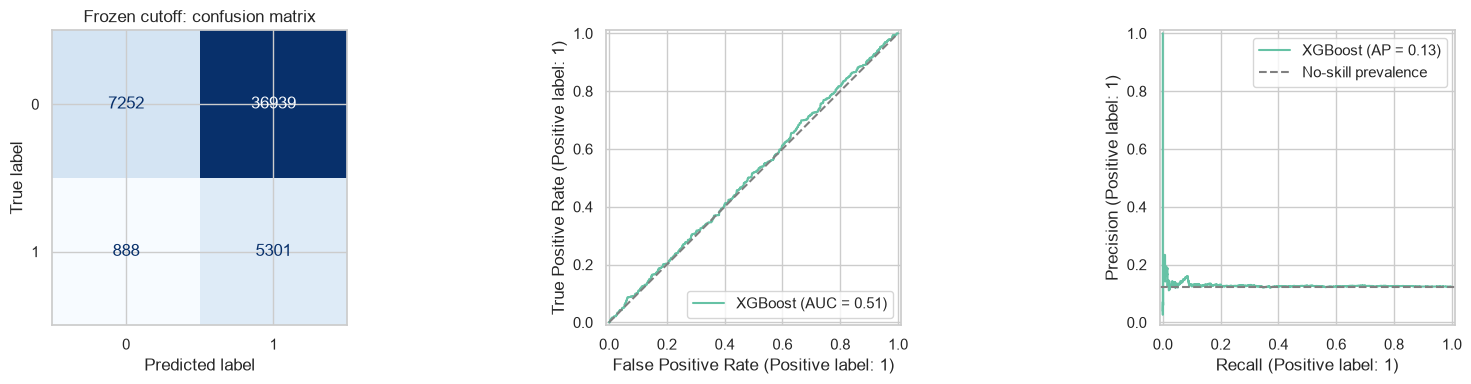

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(17, 4))
ConfusionMatrixDisplay.from_predictions(y_final, final_predictions, ax=axes[0],
                                       colorbar=False, cmap='Blues')
axes[0].set_title('Frozen cutoff: confusion matrix')
RocCurveDisplay.from_predictions(y_final, final_scores, ax=axes[1], name='XGBoost')
axes[1].plot([0, 1], [0, 1], '--', color='gray')
PrecisionRecallDisplay.from_predictions(y_final, final_scores, ax=axes[2], name='XGBoost')
axes[2].axhline(y_final.mean(), linestyle='--', color='gray', label='No-skill prevalence')
axes[2].legend()
show_plot('08_final_evaluation.png')


### 22.2 Probability calibration — diagnostic only
If cases receiving scores near 0.6 have an observed positive rate near 0.6, the model is well calibrated in that range. Points away from the diagonal show a mismatch. We inspect this without fitting a calibrator on final-validation labels. Brier score measures squared probability error (lower is better).


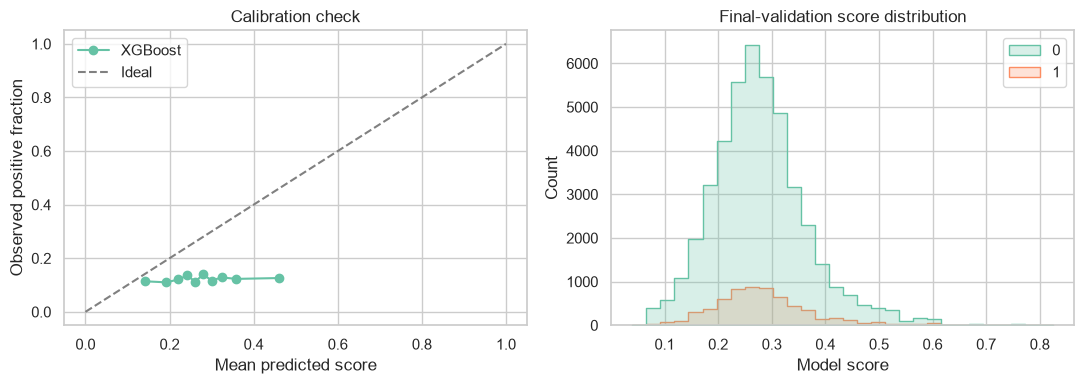

In [ ]:
observed_rate, mean_score = calibration_curve(y_final, final_scores, n_bins=10, strategy='quantile')
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].plot(mean_score, observed_rate, 'o-', label='XGBoost')
axes[0].plot([0, 1], [0, 1], '--', color='gray', label='Ideal')
axes[0].set(xlabel='Mean predicted score', ylabel='Observed positive fraction', title='Calibration check')
axes[0].legend()
sns.histplot(x=final_scores, hue=y_final.to_numpy(), bins=30, ax=axes[1], element='step')
axes[1].set(title='Final-validation score distribution', xlabel='Model score')
show_plot('09_calibration.png')


## 23. Model interpretation — built-in importance first
XGBoost's built-in importances describe which encoded features its trees use most. Importance is not direction or causation; correlated features can share credit. The next section uses SHAP to explain direction for individual predictions.


,importance
categorical__CITY_ratlam,0.012967
categorical__Profession_consultant,0.012675
categorical__CITY_sri ganganagar,0.009703
categorical__CITY_tezpur,0.009494
categorical__Profession_chartered accountant,0.009282
categorical__CITY_morena,0.008897
categorical__STATE_madhya pradesh,0.008274
categorical__STATE_punjab,0.008145
categorical__CITY_ujjain,0.008009
categorical__CITY_raurkela industrial township,0.007987


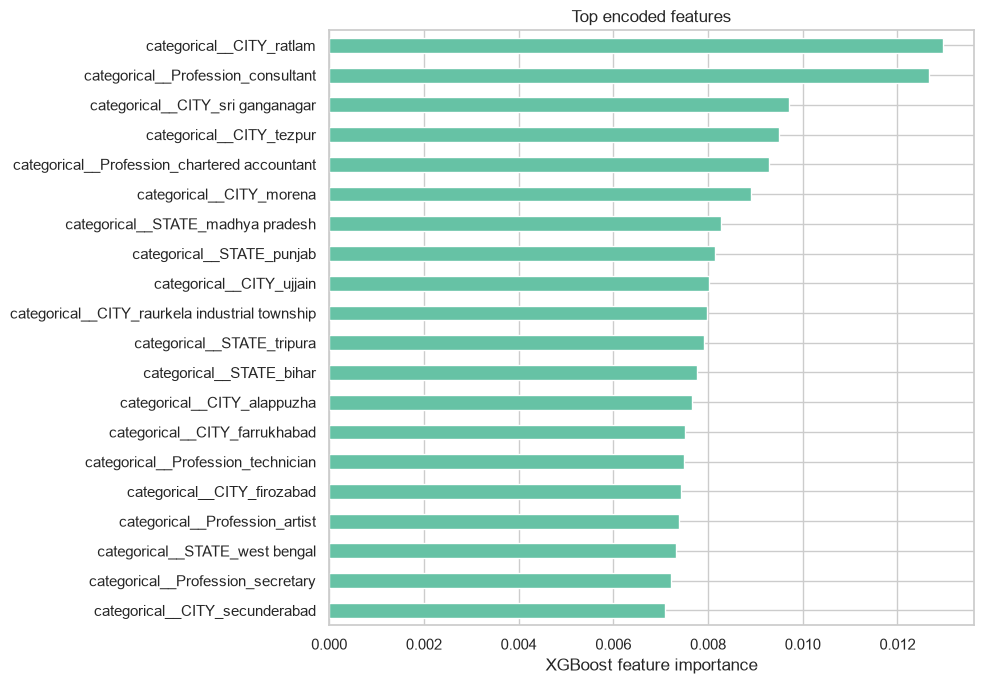

In [ ]:
feature_names = final_model.named_steps['preprocessing'].get_feature_names_out()
importance = pd.Series(final_model.named_steps['model'].feature_importances_,
                       index=feature_names).sort_values(ascending=False)
display(importance.head(15).to_frame('importance'))
importance.head(20).sort_values().plot.barh(figsize=(10, 7))
plt.xlabel('XGBoost feature importance')
plt.title('Top encoded features')
show_plot('10_feature_importance.png')
importance.to_csv(OUTPUT / 'feature_importance.csv')


## 24. SHAP — explain the model globally and locally
SHAP assigns each input feature a contribution relative to a baseline model output. Positive contributions push toward class 1; negative contributions push toward class 0.

For this tree explainer, contributions are in **raw log-odds**, not probability percentage points. Baseline + feature contributions equals the raw model output. The logistic function converts that total to the model's probability-scale score. Explanations describe model associations, not causes or a verified lending rationale.

We explain a small development sample to control memory. SHAP receives the same sparse matrix as XGBoost; converting it to dense before explanation could change how XGBoost interprets absent entries. Only the display data is converted to dense afterward. One-hot categories appear as separate features. No pipeline is refitted for SHAP.


In [ ]:
X_explain = X_dev.sample(n=min(SHAP_ROWS, len(X_dev)), random_state=SEED)
transformed = final_model.named_steps['preprocessing'].transform(X_explain)
explainer = shap.TreeExplainer(final_model.named_steps['model'], model_output='raw')
shap_values = explainer(transformed)
# Attach readable labels after explanation: some city names contain brackets.
shap_values.feature_names = feature_names.tolist()
if hasattr(transformed, 'toarray'):
    shap_values.data = transformed.toarray()  # display only; predictions used sparse data

# Verify the explanation adds up to the model's score.
raw_total = np.asarray(shap_values.base_values) + shap_values.values.sum(axis=1)
shap_score = 1 / (1 + np.exp(-raw_total))
np.testing.assert_allclose(shap_score, final_model.predict_proba(X_explain)[:, 1], atol=1e-5)
print('SHAP additivity check passed on', len(X_explain), 'rows.')


SHAP additivity check passed on 200 rows.


### 24.1 Global SHAP bar plot
Mean absolute SHAP value measures average contribution size across the explained sample. It does not show whether a feature increases or decreases risk.


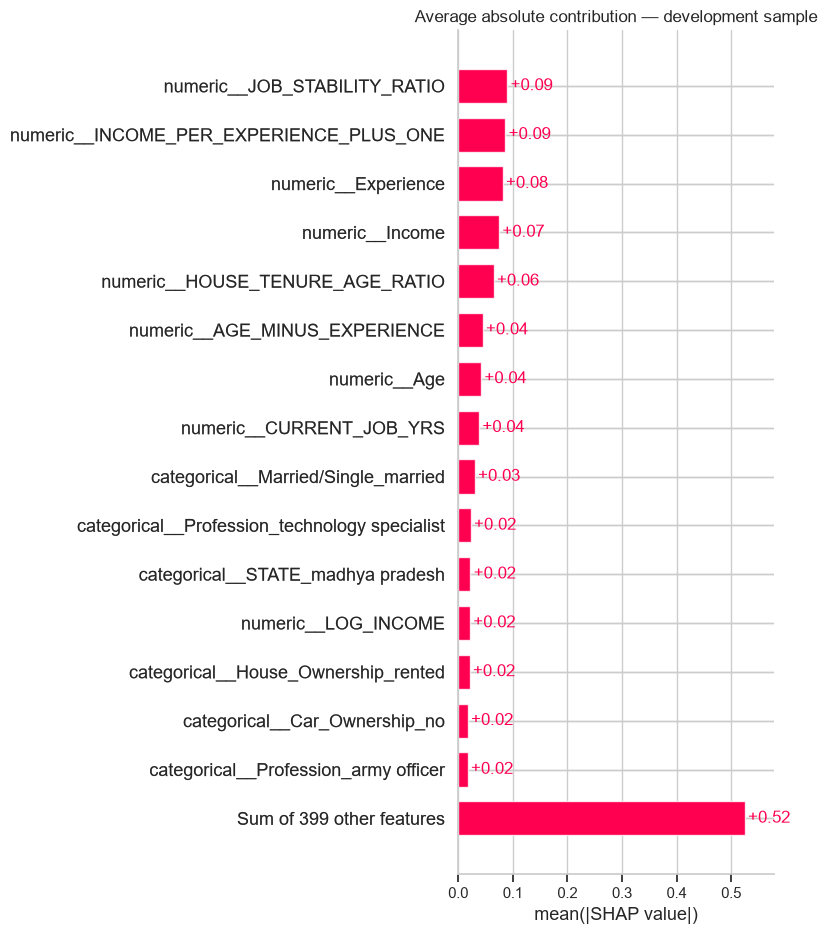

In [ ]:
shap.plots.bar(shap_values, max_display=16, show=False)
plt.title('Average absolute contribution — development sample')
show_plot('11_shap_global_bar.png')


### 24.2 SHAP beeswarm
Each dot is one applicant. Horizontal position shows its contribution; color shows the feature value. For one-hot features, high values mean the category is present. Wide spreads suggest that a feature affects applicants differently.


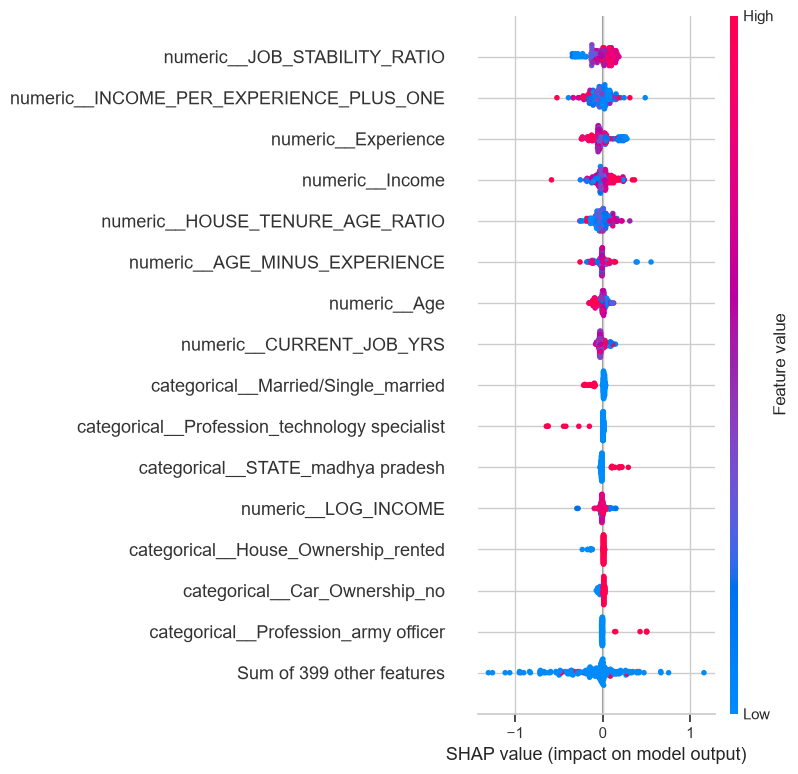

In [ ]:
shap.plots.beeswarm(shap_values, max_display=16, show=False)
show_plot('12_shap_beeswarm.png')


### 24.3 Explain one applicant with a waterfall
Read from the baseline up to this applicant's final raw score. This is a sampled development record used for explanation, not an independent performance example.


,Income,Age,Experience,CURRENT_JOB_YRS,CURRENT_HOUSE_YRS,Married/Single,House_Ownership,Car_Ownership,Profession,CITY,STATE,LOG_INCOME,INCOME_PER_EXPERIENCE_PLUS_ONE,JOB_STABILITY_RATIO,HOUSE_TENURE_AGE_RATIO,AGE_MINUS_EXPERIENCE
151061,572808.0,67.0,2.0,2.0,13.0,single,rented,no,software developer,kirari suleman nagar,delhi,13.258308,190936.0,0.666667,0.191176,65.0


Model score: 0.4292
Frozen cutoff: 0.1967


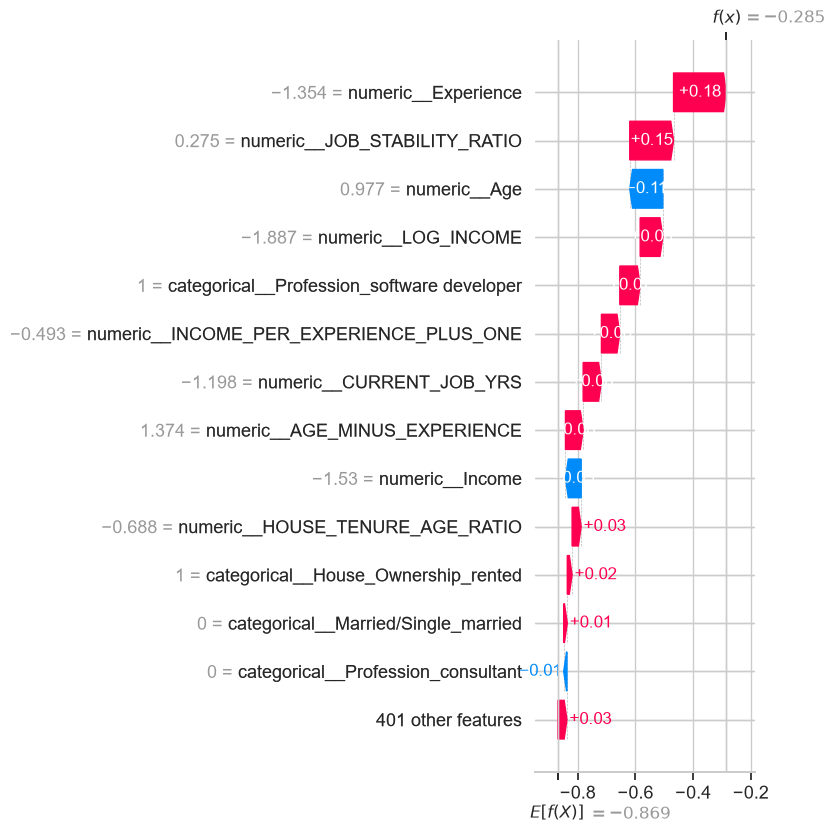

In [ ]:
display(X_explain.iloc[[0]])
print('Model score:', round(float(final_model.predict_proba(X_explain.iloc[[0]])[0, 1]), 4))
print('Frozen cutoff:', round(selected_threshold, 4))
shap.plots.waterfall(shap_values[0], max_display=14, show=False)
show_plot('13_shap_local_waterfall.png')


## 25. Save the fitted pipeline using standard-library pickle
The saved pipeline contains **fitted imputation, scaling, encoding and XGBoost**. Its input is the engineered dataframe. `clean_data` and `engineer_features` are deliberately simple functions outside the pickle; run their definition cells before using the helper below in a fresh session. The helper always applies those same formulas before prediction.

We also save the threshold, feature schema, package versions and split strategy. We preserve the evaluated model rather than silently refitting on validation data. Pickle files should only be loaded from a trusted source and with matching library versions.


In [ ]:
metadata = {'threshold': selected_threshold, 'seed': SEED, 'target': TARGET,
            'raw_features': FEATURES, 'engineered_features': X_dev.columns.tolist(),
            'versions': versions, 'python_version': platform.python_version(),
            'split_strategy': 'profile-group stratified development / threshold / final validation',
            'training_rows': len(X_dev), 'best_parameters': search.best_params_,
            'preparation': 'clean_data followed by engineer_features as defined in this notebook'}
bundle = {'pipeline': final_model, 'metadata': metadata}
with open(OUTPUT / 'loan_risk_pipeline.pkl', 'wb') as file:
    pickle.dump(bundle, file)
with open(OUTPUT / 'model_metadata.json', 'w', encoding='utf-8') as file:
    json.dump(metadata, file, indent=2)
(OUTPUT / 'requirements_used.txt').write_text(
    '\n'.join(f'{name}=={version}' for name, version in versions.items()), encoding='utf-8')
print('Saved model and metadata to:', OUTPUT.resolve())


Saved model and metadata to: C:\Users\KARUNESH G Y\Documents\Codex\2026-09-13\https-github-com-karangy7904-end-to\outputs\loan_notebook_outputs


## 26. Reload and verify predictions
Round-trip verification checks that loading the saved pipeline reproduces predictions. We also check that missing numeric data and unseen categories can pass through the fitted preprocessing recipe.


In [ ]:
with open(OUTPUT / 'loan_risk_pipeline.pkl', 'rb') as file:
    loaded_bundle = pickle.load(file)

def predict_applicants(raw_applicants, saved_bundle):
    cleaned = clean_data(raw_applicants)
    engineered = engineer_features(cleaned)
    expected_columns = saved_bundle['metadata']['engineered_features']
    assert engineered.columns.tolist() == expected_columns, 'Feature schema mismatch.'
    scores = saved_bundle['pipeline'].predict_proba(engineered)[:, 1]
    return pd.DataFrame({'Id': cleaned['Id'].to_numpy(), 'Risk_Score': scores,
                         'Risk_Flag': (scores >= saved_bundle['metadata']['threshold']).astype(int)})

reloaded_check = predict_applicants(dev.head(10), loaded_bundle)
np.testing.assert_allclose(reloaded_check['Risk_Score'],
                           final_model.predict_proba(X_dev.head(10))[:, 1])
edge_case = test_raw.head(1).copy()
edge_case.loc[edge_case.index[0], 'Income'] = np.nan
edge_case.loc[edge_case.index[0], 'CITY'] = 'previously unseen city'
assert np.isfinite(predict_applicants(edge_case, loaded_bundle)['Risk_Score']).all()
print('Save/reload and missing-value/unseen-category checks passed.')


Save/reload and missing-value/unseen-category checks passed.


## 27. Score the supplied test CSV — preserve all IDs and row order
The test file contains no labels. We generate scores and predicted flags, not test-set accuracy. We also report how many test profiles appear in development: those records have a different generalization setting from the deliberately unseen-profile final validation.


In [ ]:
test_predictions = predict_applicants(test_raw, loaded_bundle)
assert len(test_predictions) == len(test_raw)
assert np.array_equal(test_predictions['Id'].to_numpy(), test_raw['ID'].to_numpy())
assert test_predictions['Risk_Score'].between(0, 1).all()
assert set(test_predictions['Risk_Flag'].unique()).issubset({0, 1})
test_predictions.to_csv(OUTPUT / 'test_predictions.csv', index=False)
test_predictions[['Id', 'Risk_Flag']].rename(columns={'Id': 'ID'}).to_csv(
    OUTPUT / 'test_labels.csv', index=False)

test_groups = pd.util.hash_pandas_object(test[FEATURES], index=False)
print(f'Test profiles seen in development: {test_groups.isin(g_dev).mean():.2%}')
print('Predictions saved:', len(test_predictions))
display(test_predictions.head(10))
display(test_predictions['Risk_Flag'].value_counts().rename('Predicted count'))


Test profiles seen in development: 54.79%
Predictions saved: 28000


,Id,Risk_Score,Risk_Flag
0,1,0.200775,1
1,2,0.300194,1
2,3,0.299829,1
3,4,0.195212,0
4,5,0.561079,1
5,6,0.255359,1
6,7,0.296746,1
7,8,0.356121,1
8,9,0.315098,1
9,10,0.316966,1


Risk_Flag
1    22905
0     5095
Name: Predicted count, dtype: int64

## 28. Final results



In [ ]:
reported = final_metrics.iloc[1]
print(f"Final unseen-profile validation: AP={reported['AP']:.4f}, "
      f"ROC-AUC={reported['ROC_AUC']:.4f}, precision={reported['precision']:.4f}, "
      f"recall={reported['recall']:.4f}, F1={reported['F1']:.4f}.")
print(f"Threshold {selected_threshold:.4f} was selected on a separate partition.")
print(f"Saved {len(test_predictions):,} test predictions and the evaluated fitted pipeline.")


Final unseen-profile validation: AP=0.1279, ROC-AUC=0.5103, precision=0.1255, recall=0.8565, F1=0.2189.
Threshold 0.1967 was selected on a separate partition.
Saved 28,000 test predictions and the evaluated fitted pipeline.
